# Stochastic evolution of a colony of B cells

In [154]:
import matplotlib.pyplot as plt
from __future__ import annotations
import numpy as np
from numpy.random import default_rng

In [155]:
"""
Germinal‑centre B‑cell maturation with multiple antigens
========================================================

• State of each cycling B‑cell: h ∈ ℝ^{N_h} (residue binding‑energy vector)
• Antigens:            S_mat ∈ {‑1, +1}^{N_h × n_A}
                       ε_v(h) = Σ_i s_{iv} h_i    for every antigen v
• One round:           duplication → SHM → Ag‑gate → T‑gate → differentiation
• Output:              `history[step]` is a NumPy array of shape
                       (n_cells_alive_that_step, N_h) with the h‑vectors

The implementation below follows exactly the gates used in your FP solver.
"""



# --------------------- biological / model parameters -------------------
p_sil=0.75# 10-3 mutation rate times nb of amino acids=250 so total is 0.25 mutation per cycle
p_let=0.05*(1-p_sil)
p_aa=0.95*(1-p_sil)
mu_M=-0.13*np.log(10)
sigma_M=0.37*np.log(10)
T=140
E_a=3.4                        # Ag-gate threshold
kBT=1                       # thermal factor
N_i=2000  
N_max=2000 
mu_i=0.0 
sigma_i=0.1
p_diff=0.10
c=300
# global parameters (use existing values or define defaults)

# -------------------------- helper functions ---------------------------
def energies(pop: np.ndarray, S_mat: np.ndarray) -> np.ndarray:
    """
    Compute energies for every cell and every antigen.

    Parameters
    ----------
    pop   : (N_cells, N_h) ndarray
    S_mat : (N_h, n_A)     ndarray

    Returns
    -------
    eps : (N_cells, n_A) ndarray   with eps[c, v] = ε_v(h_c)
    """
    return pop @ S_mat                     # broadcasting handles dot‑product

def P_Ag(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    Antigen‑binding survival gate   P_Ag(h)

    eps   : (N_cells, n_A) energies
    C_vec : (n_A,)        antigen concentrations at current round
    """
    exp_term   = np.exp((eps - E_a) / kBT)         # same as FP code
    numer      = (exp_term * C_vec).sum(axis=1)    # Σ_v C_v e^{(ε_v - E_a)/kT}
    return numer / (1.0 + numer)

def P_T(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    T‑cell‑help survival gate   P_T(h | pop)

    eps   : (N_cells, n_A) energies *after* Ag selection
    """
    C_tot      = C_vec.sum()
    eE         = np.exp(eps / kBT)                 # e^{ε_v/kT}
    Phi        = (eE * C_vec).sum(axis=1)          # Σ_v C_v e^{ε_v/kT}
    Phi_bar    = Phi.mean()                       # ⟨Φ⟩_pop
    return Phi / (Phi + Phi_bar / C_tot)

# ----------------------- one maturation round --------------------------
def gc_round(pop: np.ndarray,
             S_mat: np.ndarray,
             C_vec: np.ndarray,
             rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """
    Advance the cycling population by one GC round.

    Returns
    -------
    pop_next : ndarray   surviving cycling cells
    mem      : ndarray   newly differentiated memory / plasma cells
    """
    # 1 Duplication ------------------------------------------------------
    pop = np.repeat(pop, 2, axis=0)               # each cell divides

    # 2 Somatic hyper‑mutation ------------------------------------------
    N_cells   = pop.shape[0]
    fate      = rng.choice(
        ["let", "aa", "sil"], size=N_cells,
        p=[p_let, p_aa, p_sil]
    )

    alive_mask = fate != "let"
    aa_mask    = fate == "aa"
    n_aa       = aa_mask.sum()

    if n_aa:
        idx_sites   = rng.integers(0, pop.shape[1], size=n_aa)
        delta_h     = rng.normal(mu_M, sigma_M, size=n_aa)
        pop[aa_mask, idx_sites] = np.clip(pop[aa_mask, idx_sites] + delta_h, -10, 10)

    pop = pop[alive_mask]                         # drop lethal daughters
    if pop.size == 0:
        return pop, np.empty((0, pop.shape[1]))

    # 3 Antigen‑binding gate --------------------------------------------
    eps      = energies(pop, S_mat)
    P_ag     = P_Ag(eps, C_vec)
    survive  = rng.random(size=P_ag.size) < P_ag
    pop      = pop[survive];  eps = eps[survive]
    if pop.size == 0:
        return pop, np.empty((0, S_mat.shape[0]))

    # 4 T‑cell‑help gate -------------------------------------------------
    P_t      = P_T(eps, C_vec)
    survive  = rng.random(size=P_t.size) < P_t
    pop      = pop[survive]
    if pop.size == 0:
        return pop, np.empty((0, S_mat.shape[0]))

    # 5 Differentiation --------------------------------------------------
    diff_mask = rng.random(size=pop.shape[0]) < p_diff
    mem_cells = pop[diff_mask]
    pop       = pop[~diff_mask]

    return pop, mem_cells

# ---------------------- full GC simulation driver ----------------------
def simulate_gc_history(rounds: int,
                        S_mat: np.ndarray,
                        N_init: int = N_i,
                        N_max: int  = N_max,
                        C_schedule = lambda r: np.array([c]),
                        mu_init: float = mu_i,
                        sigma_init: float = sigma_i,
                        seed: int | None = None
                       ) -> list[np.ndarray]:
    """
    Simulate `rounds` germinal‑centre cycles and return the full history.

    Returns
    -------
    history : list of ndarray
        history[t] has shape (n_cells_alive_at_t, N_h)
    """
    rng  = default_rng(seed)
    N_h  = S_mat.shape[0]

    # Gaussian initial repertoire
    pop = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
    history: list[np.ndarray] = [pop.copy()]

    for r in range(rounds):
        C_vec = np.asarray(C_schedule(), dtype=float)   # shape (n_A,)
        pop, _mem_cells = gc_round(pop, S_mat, C_vec, rng)

        # population cap
        if pop.shape[0] > N_max:
            keep_idx = rng.choice(pop.shape[0], N_max, replace=False)
            pop = pop[keep_idx]

        history.append(pop.copy())

    return history




In [156]:
S_mat = np.array([[1]])

# Antigen concentration decays exponentially over rounds
def C_schedule():
    return np.array([c]) 

history = simulate_gc_history(
    rounds   = T,
    S_mat    = S_mat,
    N_init   = N_i,
    N_max    = N_max,
    C_schedule = C_schedule,
    seed     = 42
)

# `history` is the requested list‑of‑arrays result
print(f"Rounds simulated: {len(history)-1}")
for t, pop in enumerate(history[:]):       # first few steps
    print(f"t={t:02d}  cycling cells={pop.shape[0]}")

Rounds simulated: 140
t=00  cycling cells=2000
t=01  cycling cells=2000
t=02  cycling cells=2000
t=03  cycling cells=2000
t=04  cycling cells=2000
t=05  cycling cells=2000
t=06  cycling cells=2000
t=07  cycling cells=2000
t=08  cycling cells=2000
t=09  cycling cells=2000
t=10  cycling cells=2000
t=11  cycling cells=2000
t=12  cycling cells=2000
t=13  cycling cells=2000
t=14  cycling cells=2000
t=15  cycling cells=2000
t=16  cycling cells=2000
t=17  cycling cells=2000
t=18  cycling cells=2000
t=19  cycling cells=2000
t=20  cycling cells=2000
t=21  cycling cells=2000
t=22  cycling cells=2000
t=23  cycling cells=2000
t=24  cycling cells=2000
t=25  cycling cells=2000
t=26  cycling cells=2000
t=27  cycling cells=2000
t=28  cycling cells=2000
t=29  cycling cells=2000
t=30  cycling cells=2000
t=31  cycling cells=2000
t=32  cycling cells=2000
t=33  cycling cells=2000
t=34  cycling cells=2000
t=35  cycling cells=2000
t=36  cycling cells=2000
t=37  cycling cells=2000
t=38  cycling cells=2000
t=3

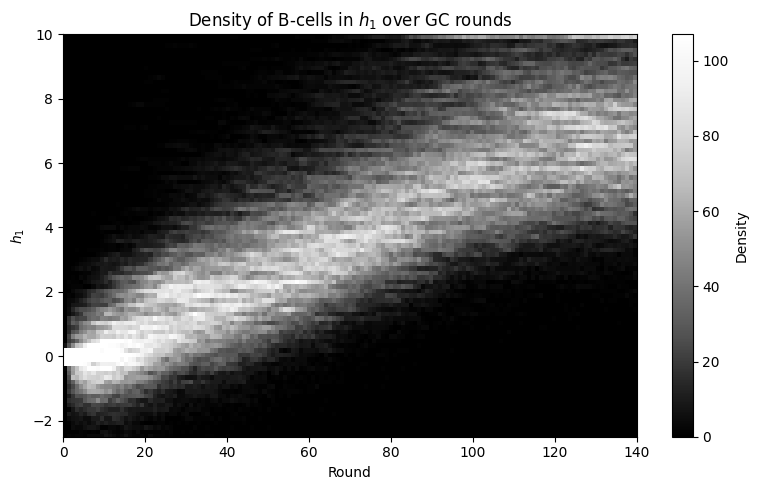

In [158]:
import matplotlib.pyplot as plt

# Extract (time step, h1) pairs
time_points = []
h1_values = []

for t, pop in enumerate(history):
    time_points.extend([t] * pop.shape[0])  # replicate time index
    h1_values.extend(pop[:, 0])             # extract h1 values

# Create the 2D histogram (density plot)
import numpy as np
import matplotlib.pyplot as plt

# --- parameters and raw data ------------------------------------------
t_clip = 50
rounds = np.asarray(time_points)
h_vals = np.asarray(h1_values)

# --- define bins ------------------------------------------------------
n_rounds = len(history)
n_hbins  = 100
round_bins = np.linspace(rounds.min(), rounds.max(), n_rounds + 1)
h_bins    = np.linspace(h_vals.min(), h_vals.max(), n_hbins + 1)

# --- compute 2D histogram manually ------------------------------------
H, xedges, yedges = np.histogram2d(rounds, h_vals, bins=[round_bins, h_bins])

# --- clip color scale using t ≥ t_clip --------------------------------
idx_clip = np.searchsorted(xedges, t_clip)
vmax_clip = H[idx_clip:].max()

# --- plot using imshow ------------------------------------------------
plt.figure(figsize=(8, 5))
im = plt.imshow(H.T, origin="lower", aspect="auto",
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                cmap="Greys_r", vmin=0.0, vmax=vmax_clip)
plt.xlabel("Round")
plt.ylabel(r"$h_1$")
plt.title(r"Density of B-cells in $h_1$ over GC rounds")
plt.colorbar(im, label="Density")
plt.tight_layout()
plt.ylim(-2.5, 10)
plt.show()




# Linages

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

# ----------------------------------------------------------------------


# ----------------------------------------------------------------------
def energies(h_mat, S_mat):
    return h_mat @ S_mat

def P_Ag(eps, C_vec):
    exp_term = np.exp((eps - E_a) / kBT)
    numer = (exp_term * C_vec).sum(axis=1)
    return numer / (1.0 + numer)

def P_T(eps, C_vec):
    C_tot = C_vec.sum()
    Phi = (np.exp(eps / kBT) * C_vec).sum(axis=1)
    Phi_bar = Phi.mean()
    return Phi / (Phi + Phi_bar / C_tot)

# ----------------------------------------------------------------------
def simulate_with_genealogy(rounds,
                            S_mat,
                            C_schedule,
                            N_init=N_i, N_max=N_max,
                            mu_init=mu_i, sigma_init=sigma_i,
                            seed=None):
    """
    Returns
    -------
    history : list[dict]      snapshot r   → {cell_id: h_vec}
    parents : dict            child_id → parent_id (root parents not included)
    """
    rng = default_rng(seed)
    N_h = S_mat.shape[0]

    # initial repertoire
    pop_h = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
    pop_id = np.arange(N_init)               # 0..N_init-1
    next_id = N_init

    parents = {}                             # genealogy graph
    history = [dict(zip(pop_id, pop_h.copy()))]  # round 0 snapshot

    for r in range(rounds):
        # ------ duplication -------------------------------------------------
        pop_h = np.repeat(pop_h, 2, axis=0)          # (2N, N_h)
        parent_ids = np.repeat(pop_id, 2)            # (2N,)

        new_ids = np.arange(next_id, next_id + pop_h.shape[0])
        next_id += pop_h.shape[0]
        # register genealogy
        parents.update({cid: pid for cid, pid in zip(new_ids, parent_ids)})

        pop_id = new_ids                              # adopt new IDs

        # ------ somatic hyper‑mutation -------------------------------------
        fate = rng.choice(["let", "aa", "sil"], size=pop_h.shape[0],
                          p=[p_let, p_aa, p_sil])
        alive_mask = fate != "let"
        aa_mask = fate == "aa"
        if aa_mask.any():
            idx = rng.integers(0, N_h, size=aa_mask.sum())
            pop_h[aa_mask, idx] = np.clip(pop_h[aa_mask, idx]+rng.normal(mu_M, sigma_M, size=aa_mask.sum()),-10, 10)

        pop_h, pop_id = pop_h[alive_mask], pop_id[alive_mask]
        if pop_h.size == 0:
            history.append({})          # empty snapshot
            break

        # ------ Ag binding gate --------------------------------------------
        eps = energies(pop_h, S_mat)
        survive = rng.random(pop_h.shape[0]) < P_Ag(eps, C_schedule())
        pop_h, pop_id, eps = pop_h[survive], pop_id[survive], eps[survive]
        if pop_h.size == 0:
            history.append({})
            break

        # ------ T‑cell help gate -------------------------------------------
        survive = rng.random(pop_h.shape[0]) < P_T(eps, C_schedule())
        pop_h, pop_id = pop_h[survive], pop_id[survive]
        if pop_h.size == 0:
            history.append({})
            break

        # ------ differentiation (exit GC) ----------------------------------
        stay = rng.random(pop_h.shape[0]) >= p_diff
        pop_h, pop_id = pop_h[stay], pop_id[stay]

        # ------ GC size cap -------------------------------------------------
        if pop_h.shape[0] > N_max:
            keep_idx = rng.choice(pop_h.shape[0], N_max, replace=False)
            pop_h, pop_id = pop_h[keep_idx], pop_id[keep_idx]

        history.append(dict(zip(pop_id, pop_h.copy())))

    return history, parents

# ----------------------------------------------------------------------
def lineage_trajectory(leaf_id, history, parents):
    """
    Reconstruct (round, h1) along the lineage of `leaf_id`.
    Assumes exactly one division per round.
    """
    rounds = []
    h1_vals = []
    cid = leaf_id
    for r in range(len(history)-1, -1, -1):   # from last to first
        snapshot = history[r]
        if cid not in snapshot:
            # lineage ancestor was already dead -> stop
            break
        rounds.append(r)
        h1_vals.append(snapshot[cid][0])      # h1 coordinate
        cid = parents.get(cid, None)          # climb to parent
        if cid is None:
            break
    rounds.reverse()
    h1_vals.reverse()
    return rounds, h1_vals

# ----------------------------------------------------------------------
# Example run -----------------------------------------------------------
S_mat = np.array([[1], [1]])
def C_schedule():
    return np.array([c])

history, parents = simulate_with_genealogy(
    rounds=T,
    S_mat=S_mat,
    C_schedule=C_schedule,
    seed=1
)

# pick leaves meeting threshold
target = 8
leaf_ids = [cid for cid, h in history[-1].items() if target+0.5>=h[0] >= target-0.5]
print(f"Leaves meeting h1 ≥ {target}: {len(leaf_ids)}")

# plot trajectories
t_max = len(history) - 1



Leaves meeting h1 ≥ 8: 131


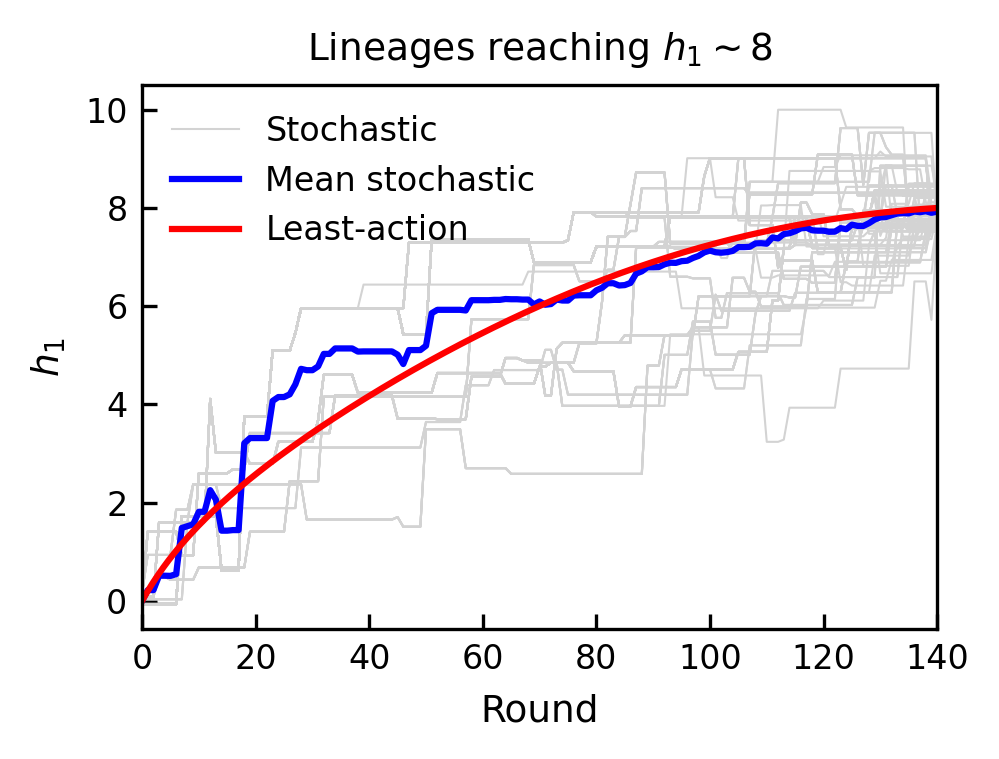

In [172]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib import rcParams

# --- PRL-style font and layout settings ------------------------------
rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "legend.fontsize": 8,
    "figure.figsize": (3.4, 2.6),  # ~8.6cm × 6.6cm
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# --- Load trajectory from CSV ----------------------------------------
h_sol = np.loadtxt("../multi Ag/trajectory_h_140.csv", delimiter=",")
T = 140
n_points = len(h_sol)
t_sol = np.linspace(0, T, n_points)

# --- Prepare B-cell lineage trajectories ------------------------------
h1_by_round = defaultdict(list)
fig, ax = plt.subplots()
first = True

for cid in leaf_ids:
    rounds, h1 = lineage_trajectory(cid, history, parents)
    for t, h in zip(rounds, h1):
        h1_by_round[t].append(h)
    if first:
        ax.plot(rounds, h1, lw=0.5, color='lightgrey', label='Stochastic')
        first = False
    else:
        ax.plot(rounds, h1, lw=0.5, color='lightgrey')

# --- Plot mean trajectory in blue -------------------------------------
common_rounds = sorted(h1_by_round.keys())
mean_h1 = [np.mean(h1_by_round[t]) for t in common_rounds]
ax.plot(common_rounds, mean_h1, lw=1.5, color='blue', label='Mean stochastic')

# --- Plot least-action trajectory in red ------------------------------
ax.plot(t_sol, h_sol, lw=1.5, color='red', label='Least-action')

# --- Final formatting -------------------------------------------------
ax.set_xlim(0, t_max)
ax.set_xlabel("Round")
ax.set_ylabel(r"$h_1$")
ax.legend(frameon=False, loc="upper left")
ax.set_title(r"Lineages reaching $h_1 \sim {}$".format(target))
fig.tight_layout()
plt.show()


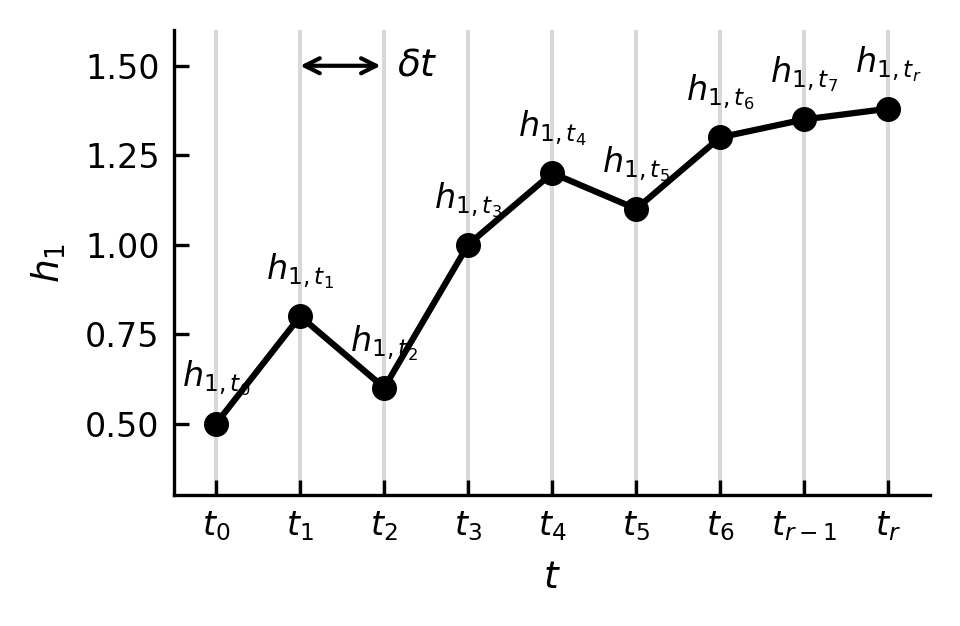

In [178]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sample data resembling schematic trajectory -------------------------
t = np.arange(9)
h = np.array([0.5, 0.8, 0.6, 1.0, 1.2, 1.1, 1.3, 1.35, 1.38])  # example h₁,t values

# --- Create plot ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(3.2, 2.2))  # PRL single column sizing

# Plot points and lines
ax.plot(t, h, 'k-', marker='o', markersize=5, linewidth=1.5)

# Vertical time ticks
for ti in t:
    ax.axvline(ti, color='grey', alpha=0.3, linestyle='-', zorder=0)

# Label each point with h_{1,t_i}
for i, (ti, hi) in enumerate(zip(t, h)):
    label = r"$h_{1,t_{%d}}$" % i if i not in [0, len(t)-1] else (
        r"$h_{1,t_0}$" if i == 0 else r"$h_{1,t_r}$")
    ax.text(ti, hi + 0.07, label, ha='center', va='bottom', fontsize=8)

# Time axis labels
ax.set_xticks(t)
xticklabels = [r"$t_0$", r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_{r-1}$", r"$t_r$"]
ax.set_xticklabels(xticklabels, rotation=0)

# Axes labels
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$h_1$")

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Delta t annotation
ax.annotate(r"$\delta t$",
            xy=(0.9, 1.5), xytext=(2.4, 1.5),
            arrowprops=dict(arrowstyle='<->', lw=1),
            ha='center', va='center', fontsize=9)

# Format
ax.tick_params(direction='in')
ax.set_xlim(-0.5, t[-1] + 0.5)
ax.set_ylim(0.3, 1.6)
fig.tight_layout()
plt.show()
